# Mahalanobis Distance to SHAP Vectors of Current Round

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import confusion_matrix
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3"
# RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0"
BASE_PATH = Path("../experiments/shap_outputs") / RUN_NAME
IQR_MULT = 1.5  # flag if distance is outside [Q1 - IQR_MULT*IQR, Q3 + IQR_MULT*IQR]

print(f"Run      : {RUN_NAME}")
print(f"Path     : {BASE_PATH}")
print(f"IQR mult : {IQR_MULT}")

Run      : fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0
Path     : ../experiments/shap_outputs/fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0
IQR mult : 1.5


In [2]:
# ── Loaders & distance functions ───────────────────────────────────────────────


def load_json(path):
    try:
        with open(path) as f:
            return json.load(f)
    except Exception:
        return {}


def load_npz_vector(path):
    """Load first array from .npz and reduce to a 1-D per-feature vector."""
    try:
        z = np.load(path, allow_pickle=True)
        arr = np.asarray(z[list(z.keys())[0]])
        if arr.ndim == 0:
            return np.array([float(arr)])
        if arr.ndim == 1:
            return arr
        return np.mean(arr, axis=0)  # (n_samples, n_features) -> (n_features,)
    except Exception:
        return None


def round_median(vectors):
    """Compute the coordinate-wise median SHAP vector for a round."""
    return np.median(np.vstack(vectors), axis=0)


# metadata
# source

client_data = defaultdict(dict)
round_dirs = sorted(
    [d for d in BASE_PATH.iterdir() if d.is_dir() and d.name.startswith("round_")]
)

print(f"Found {len(round_dirs)} rounds.")

for rdir in round_dirs:
    rnum = int(rdir.name.split("_")[1])
    for cdir in sorted([d for d in rdir.iterdir() if d.is_dir()]):
        cid = cdir.name
        meta = load_json(cdir / "metadata.json")
        sv = load_npz_vector(cdir / "shap_values.npz")
        if sv is None:
            continue
        if cid not in client_data:
            client_data[cid] = {
                "is_malicious": bool(
                    meta.get("malicious", meta.get("is_malicious", False))
                ),
                "rounds": {},
            }
        client_data[cid]["rounds"][rnum] = sv

n_mal = sum(1 for c in client_data.values() if c["is_malicious"])
n_ben = sum(1 for c in client_data.values() if not c["is_malicious"])
print(f"Clients loaded : {len(client_data)}  |  malicious: {n_mal}  |  benign: {n_ben}")

Found 17 rounds.
Clients loaded : 30  |  malicious: 6  |  benign: 24


In [3]:


def mahalanobis_distance(x, mean, cov=None, cov_inv=None, reg=1e-6):
    """
    Mahalanobis distance between 1-D vector `x` and `mean`.
    Provide either `cov_inv` (inverse covariance) or `cov` (covariance matrix).
    `reg` is a small diagonal regularizer for numerical stability.

    Returns:
        float
    """
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    delta = x - mean

    if cov_inv is None:
        if cov is None:
            # fallback: can't compute Mahalanobis without covariance info
            return float(np.linalg.norm(delta))
        cov = np.asarray(cov, dtype=float)
        cov_inv = np.linalg.pinv(cov + reg * np.eye(cov.shape[0]))

    try:
        dist2 = float(np.dot(delta, cov_inv.dot(delta)))
        return float(np.sqrt(max(dist2, 0.0)))
    except Exception:
        return float(np.linalg.norm(delta))

In [4]:
all_rounds = sorted({r for c in client_data.values() for r in c["rounds"]})
records = []

for rnum in all_rounds:
    vectors_this_round = {
        cid: cinfo["rounds"][rnum]
        for cid, cinfo in client_data.items()
        if rnum in cinfo["rounds"]
    }
    if len(vectors_this_round) < 3:
        continue

    round_center = round_median(list(vectors_this_round.values()))

    # Build covariance matrix for the round and compute a stable inverse (regularized).
    vals = np.vstack(list(vectors_this_round.values()))
    try:
        cov = np.cov(vals, rowvar=False)
        reg = 1e-6 * np.eye(cov.shape[0])
        cov_inv = np.linalg.pinv(cov + reg)
    except Exception:
        cov_inv = np.linalg.pinv(
            np.cov(vals, rowvar=False) + 1e-6 * np.eye(vals.shape[1])
        )

    for cid, sv in vectors_this_round.items():
        records.append(
            {
                "round": rnum,
                "client": cid,
                "is_malicious": client_data[cid]["is_malicious"],
                "mahalanobis_distance": mahalanobis_distance(sv, round_center, cov_inv),
            }
        )

df = pd.DataFrame(records)
print(
    f"Score table: {len(df)} rows  |  rounds: {df['round'].nunique()}  |  clients: {df['client'].nunique()}"
)
print()
print(df.groupby("is_malicious")["mahalanobis_distance"].describe().T)

Score table: 510 rows  |  rounds: 17  |  clients: 30

is_malicious       False       True 
count         408.000000  102.000000
mean            0.012627    0.036603
std             0.014338    0.030009
min             0.000369    0.000550
25%             0.002602    0.011156
50%             0.007233    0.029060
75%             0.018177    0.053808
max             0.099035    0.110203


In [5]:
# # ── Optional z-score flagging ──────────────────────────────────────────────────
# round_stats = (
#     df.groupby('round')['mahalanobis_distance']
#     .agg(['mean', 'std'])
#     .rename(columns={'mean': 'dist_mu', 'std': 'dist_sigma'})
#     .reset_index()
# )
#
# df = df.merge(round_stats, on='round')
# df['flagged'] = df['mahalanobis_distance'] > (df['dist_mu'] + 2.0 * df['dist_sigma'])
#
# print("Per-round flag counts:")
# print(df.groupby('round')['flagged'].sum().rename('n_flagged').to_frame())


In [6]:
# ── Per-round IQR flagging on Mahalanobis distance ──────────────────────────────
round_stats = (
    df.groupby("round")["mahalanobis_distance"]
    .agg(
        mah_q1=lambda x: x.quantile(0.25),
        mah_q3=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

round_stats["mah_iqr"] = round_stats["mah_q3"] - round_stats["mah_q1"]
round_stats["mah_lower"] = round_stats["mah_q1"] - IQR_MULT * round_stats["mah_iqr"]
round_stats["mah_upper"] = round_stats["mah_q3"] + IQR_MULT * round_stats["mah_iqr"]

# Merge back and flag outliers
df = df.merge(round_stats, on="round")
df["flagged"] = (df["mahalanobis_distance"] < df["mah_lower"]) | (
    df["mahalanobis_distance"] > df["mah_upper"]
)
print("Per-round flag counts:")
print(df.groupby("round")["flagged"].sum().rename("n_flagged").to_frame())

# Optional: rank the most suspicious clients in each round by largest Mahalanobis distance.
TOP_K = 3
topk_per_round = (
    df.sort_values(["round", "mahalanobis_distance"], ascending=[True, False])
    .groupby("round")
    .head(TOP_K)
    .loc[:, ["round", "client", "is_malicious", "mahalanobis_distance", "flagged"]]
)

print(f"\nTop-{TOP_K} suspicious clients per round:")
print(topk_per_round.to_string(index=False))

Per-round flag counts:
       n_flagged
round           
1              0
2              0
3              0
4              2
5              0
6              1
7              0
8              0
9              0
10             0
11             0
12             1
13             0
14             6
15             0
16             0
17             5

Top-3 suspicious clients per round:
 round    client  is_malicious  mahalanobis_distance  flagged
     1  client_9          True              0.003762    False
     1 client_28          True              0.003194    False
     1  client_6         False              0.002840    False
     2  client_2         False              0.007041    False
     2 client_15         False              0.006297    False
     2 client_18          True              0.006062    False
     3 client_24          True              0.011565    False
     3  client_9          True              0.010524    False
     3 client_15         False              0.009859    Fal

## Score Visualisation

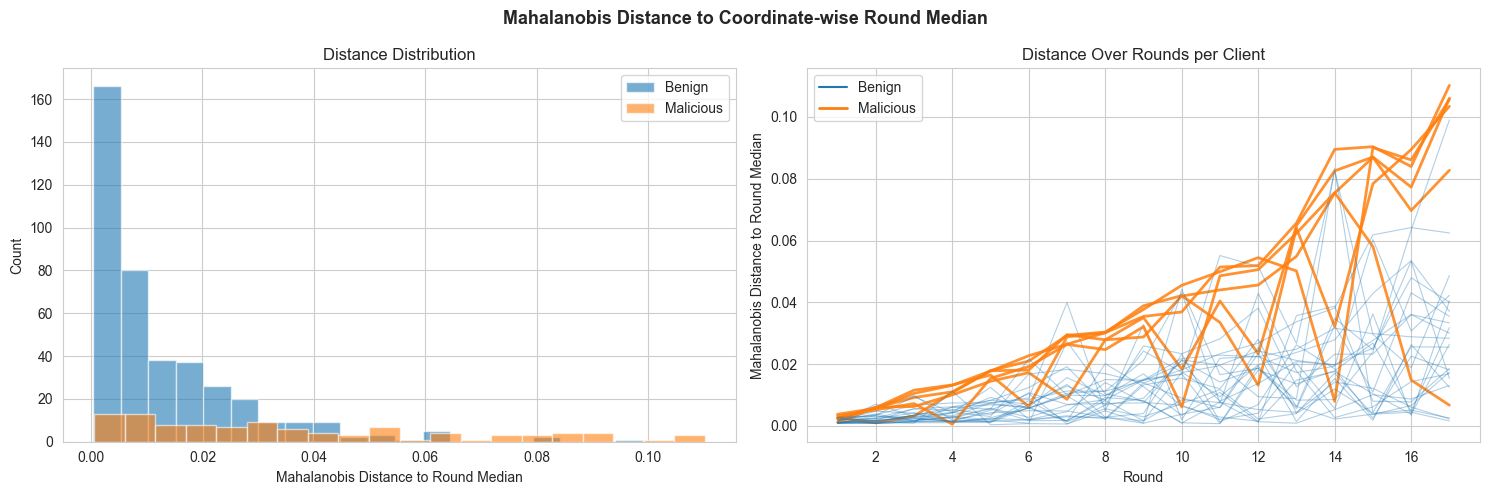

In [7]:
# ── Distribution + evolution over rounds ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram by ground-truth label
ax = axes[0]
for label, grp in df.groupby("is_malicious"):
    color = "tab:orange" if label else "tab:blue"
    name = "Malicious" if label else "Benign"
    ax.hist(
        grp["mahalanobis_distance"],
        bins=20,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor="white",
    )
ax.set_xlabel("Mahalanobis Distance to Round Median")
ax.set_ylabel("Count")
ax.set_title("Distance Distribution")
ax.legend()

# Right: score trajectory per client across rounds
ax = axes[1]
for cid, grp in df.groupby("client"):
    is_mal = grp["is_malicious"].iloc[0]
    color = "tab:orange" if is_mal else "tab:blue"
    alpha = 0.85 if is_mal else 0.35
    lw = 2.0 if is_mal else 0.8
    ax.plot(
        grp["round"],
        grp["mahalanobis_distance"],
        color=color,
        alpha=alpha,
        linewidth=lw,
    )

legend_elements = [
    Line2D([0], [0], color="tab:blue", linewidth=1.5, label="Benign"),
    Line2D([0], [0], color="tab:orange", linewidth=2.0, label="Malicious"),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Round")
ax.set_ylabel("Mahalanobis Distance to Round Median")
ax.set_title("Distance Over Rounds per Client")

plt.suptitle(
    "Mahalanobis Distance to Coordinate-wise Round Median",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

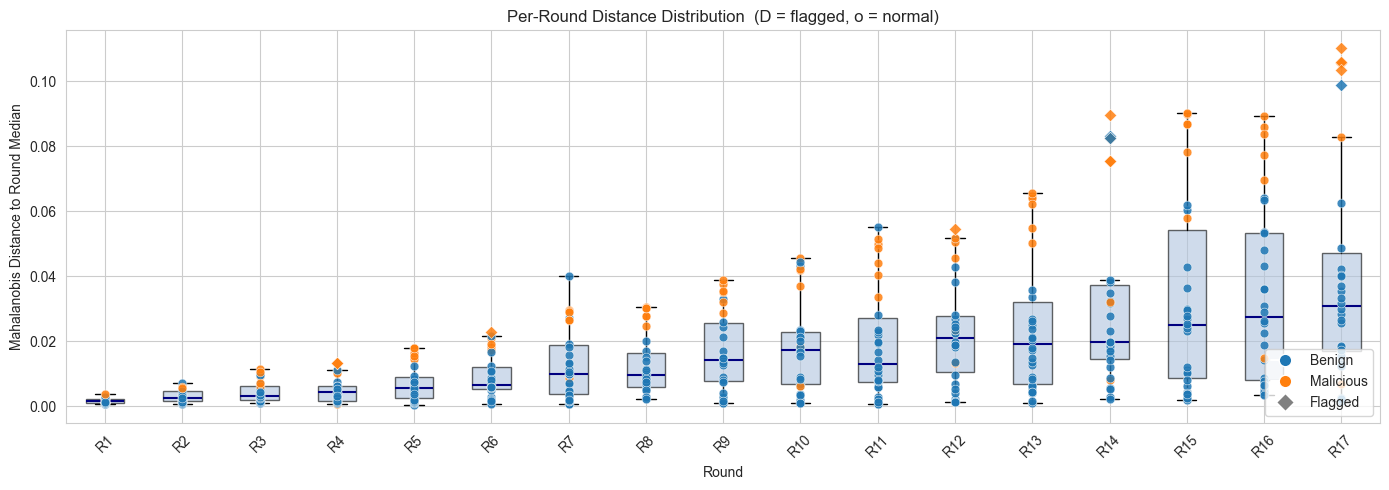

In [8]:
# ── Per-round box plot: score spread with flagged points highlighted ───────────
fig, ax = plt.subplots(figsize=(14, 5))

round_order = sorted(df["round"].unique())
positions = list(range(len(round_order)))
round_groups = [
    df[df["round"] == r]["mahalanobis_distance"].values for r in round_order
]

bp = ax.boxplot(
    round_groups,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightsteelblue", alpha=0.6),
    medianprops=dict(color="navy", linewidth=1.5),
)

# Overlay individual points, coloured by ground truth
for pos, rnum in zip(positions, round_order):
    rdf = df[df["round"] == rnum]
    for _, row in rdf.iterrows():
        color = "tab:orange" if row["is_malicious"] else "tab:blue"
        marker = "D" if row["flagged"] else "o"
        zorder = 5 if row["flagged"] else 3
        ax.scatter(
            pos,
            row["mahalanobis_distance"],
            color=color,
            s=40,
            marker=marker,
            zorder=zorder,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
        )

ax.set_xticks(positions)
ax.set_xticklabels([f"R{r}" for r in round_order], rotation=45)
ax.set_xlabel("Round")
ax.set_ylabel("Mahalanobis Distance to Round Median")
ax.set_title("Per-Round Distance Distribution  (D = flagged, o = normal)")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:blue",
        markersize=9,
        label="Benign",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:orange",
        markersize=9,
        label="Malicious",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="grey",
        markersize=9,
        label="Flagged",
    ),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df["is_malicious"].astype(int)
y_pred = df["flagged"].astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("=" * 40)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print("-" * 40)
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 40)

  TP=12  FP=3  FN=90  TN=405
----------------------------------------
  Precision : 0.8000
  Recall    : 0.1176
  F1 Score  : 0.2051
